# Análisis exploratorio de datos (EDA)

> Cómo conocer un conjunto de datos antes de limpiarlo o modelarlo: resumir cada variable, estudiar cómo se relacionan entre sí y con la variable objetivo, y detectar problemas y patrones.
>
> **Relacionado:** [Limpieza de datos](02-limpieza-datos.ipynb), [Estadística descriptiva](../02-estadistica/01-estadistica-descriptiva.ipynb), [Muestreo y desbalanceo](04-muestreo-y-desbalanceo.ipynb)

## 1. Idea clave

El **análisis exploratorio de datos** (*exploratory data analysis*, EDA) es el primer contacto serio con los datos: resúmenes numéricos y gráficos para entender qué contiene cada variable y cómo se relacionan, **antes** de decidir cómo limpiar, transformar o modelar.

Responde a preguntas como:

- ¿Qué tipo tiene cada variable y cómo se distribuye? ¿Hay asimetría, valores extraños o datos que faltan?
- ¿Está equilibrada la variable objetivo?
- ¿Qué variables parecen relacionarse con la objetivo, y entre sí?

No demuestra nada (para eso está la estadística inferencial), pero orienta todo lo que viene después: qué limpiar, qué transformar, qué variables usar y qué modelo tiene sentido. Dentro de CRISP-DM corresponde a la fase de **comprensión de los datos**.

## 2. Conceptos importantes

### 2.1. Análisis univariante: una variable cada vez

Qué se mira depende del tipo de variable (ver [tipos de variable](02-limpieza-datos.ipynb#2.1.-Tipos-de-variable)):

- **Categóricas**: frecuencias absolutas y relativas (tabla de frecuencias, diagrama de barras), número de categorías (**cardinalidad**) y categorías muy raras.
- **Numéricas**: tres aspectos de la distribución, cada uno con sus medidas.

| Aspecto | Medida clásica | Medida robusta | Gráfico |
|---|---|---|---|
| **Centro** | media $\bar{x} = \frac{1}{n}\sum_{i} x_i$ | mediana | histograma |
| **Dispersión** | desviación típica $s$ | rango intercuartílico $RIC = Q_3 - Q_1$ | diagrama de caja |
| **Forma** | asimetría (*skewness*) | comparar media y mediana | histograma |

La **asimetría** mide hacia qué lado se alarga la distribución:

$$
g_1 = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3
$$

- $g_1 \approx 0$: simétrica (media ≈ mediana).
- $g_1 > 0$: cola larga a la derecha (media > mediana). Es típico de precios, ingresos o tiempos.
- $g_1 < 0$: cola larga a la izquierda.

Como regla orientativa, $|g_1| > 1$ indica una asimetría fuerte. Cuando esto ocurre, la mediana y el RIC describen mejor los datos que la media y $s$.

### 2.2. Análisis bivariante: relaciones entre dos variables

La herramienta adecuada depende de los tipos de las dos variables:

| Par de variables | Resumen numérico | Gráfico |
|---|---|---|
| Numérica – numérica | Correlación (Pearson, Spearman) | Diagrama de dispersión, mapa de calor de correlaciones |
| Categórica – numérica | Estadísticos por grupo (`groupby`) | Diagramas de caja o histogramas por grupo |
| Categórica – categórica | Tabla de contingencia (en proporciones) | Barras normalizadas al 100 % |

Cuando una de las dos es la **variable objetivo**, este análisis da una primera idea de qué atributos pueden ser útiles para predecirla.

### 2.3. Correlación: Pearson y Spearman

La **correlación de Pearson** mide la fuerza de la relación **lineal** entre dos variables numéricas $x$ e $y$:

$$
r = \frac{\sum_{i}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i}(x_i - \bar{x})^2}\,\sqrt{\sum_{i}(y_i - \bar{y})^2}} \in [-1, 1]
$$

- $r = 1$ o $r = -1$: relación lineal perfecta (creciente o decreciente).
- $r = 0$: no hay relación **lineal**, pero puede haber otra.

Pearson es sensible a los atípicos y a la asimetría, y supone que las dos variables son de intervalo.

La **correlación de Spearman** $\rho$ es la de Pearson aplicada a los **rangos**: se sustituye cada valor por su posición al ordenar. Mide relaciones **monótonas** (que siempre crecen o siempre decrecen, aunque no sea en línea recta). Por eso:

- es robusta frente a atípicos y asimetría;
- sirve para variables **ordinales**, como la clase de un billete o una gravedad de 0 a 3.

Dos advertencias que conviene recordar siempre:

1. **Correlación no implica causalidad.** Dos variables pueden moverse juntas porque ambas dependen de una tercera.
2. **Una correlación cercana a 0 no significa que no haya relación.** Una relación en forma de U, o que solo afecta a un rango de valores, puede dar $r \approx 0$.

## 3. Código

Usamos el conjunto **Titanic** de `seaborn` (891 pasajeros). Es una versión preprocesada por seaborn de los datos de la competición *Titanic* de Kaggle: se han quitado las columnas que identifican al pasajero (id, nombre, billete, camarote) y se han añadido columnas derivadas (`class`, `who`, `alive`, `alone`…). La variable objetivo es `survived` (1 = sobrevive).

### 3.1. Visión general

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)

In [2]:
df = sns.load_dataset("titanic")

# Quitamos las columnas derivadas que repiten información de otras
df = df.drop(columns=["class", "alive", "embark_town", "who", "adult_male", "alone"])

print(df.shape)
df.head()

(891, 9)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN


In [3]:
# Tipos y valores perdidos por columna
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "% perdidos": df.isna().mean().mul(100).round(1),
})
resumen

,tipo,n_unicos,% perdidos
survived,int64,2,0.0
pclass,int64,3,0.0
sex,str,2,0.0
age,float64,88,19.9
sibsp,int64,7,0.0
parch,int64,7,0.0
fare,float64,248,0.0
embarked,str,3,0.2
deck,category,7,77.2


Con esta tabla ya se ven tres cosas que habrá que tratar en la [limpieza](02-limpieza-datos.ipynb):
- `survived` y `pclass` son categóricas guardadas como números;
- `deck` casi no tiene datos (77 % perdido);
- `age` tiene un 20 % de valores perdidos.

### 3.2. Univariante: variables categóricas

In [4]:
categoricas = ["survived", "pclass", "sex", "embarked"]

# Frecuencias relativas; dropna=False para ver también los perdidos
for col in categoricas:
    print(col, df[col].value_counts(normalize=True, dropna=False).round(3).to_dict())

survived {0: 0.616, 1: 0.384}
pclass {3: 0.551, 1: 0.242, 2: 0.207}
sex {'male': 0.648, 'female': 0.352}
embarked {'S': 0.723, 'C': 0.189, 'Q': 0.086, nan: 0.002}


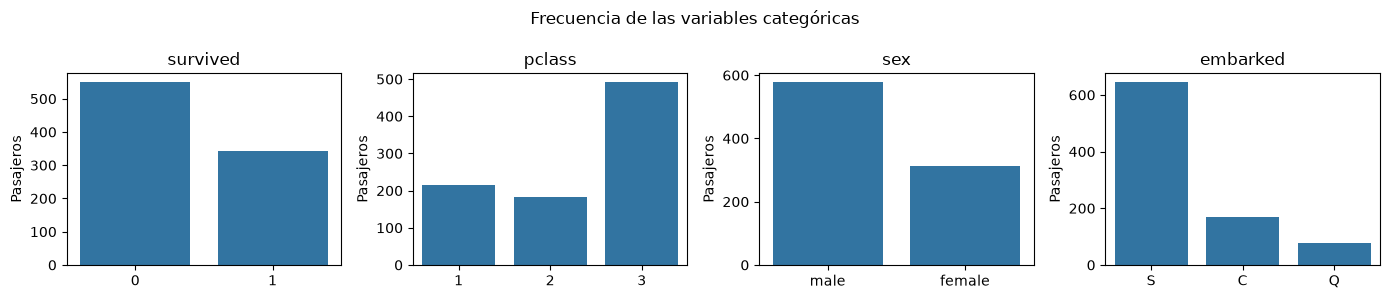

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col in zip(axes, categoricas):
    sns.countplot(data=df, x=col, ax=ax, color="tab:blue")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Pasajeros")
fig.suptitle("Frecuencia de las variables categóricas")
plt.tight_layout()
plt.show()

- La objetivo está **moderadamente desbalanceada**: sobrevive el 38 %. Hay que tenerlo en cuenta al evaluar modelos (ver [muestreo y desbalanceo](04-muestreo-y-desbalanceo.ipynb)).
- Más de la mitad de los pasajeros viajaba en 3.ª clase y casi dos tercios eran hombres.
- `embarked` tiene una categoría dominante (`S`, 72 %) y 2 valores perdidos.

### 3.3. Univariante: variables numéricas

In [6]:
numericas = ["age", "fare", "sibsp", "parch"]

descr = df[numericas].describe().T
descr["asimetria"] = df[numericas].skew()
descr.round(2)

,count,mean,std,min,25%,50%,75%,max,asimetria
age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00,0.39
fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33,4.79
sibsp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00,3.70
parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00,2.75


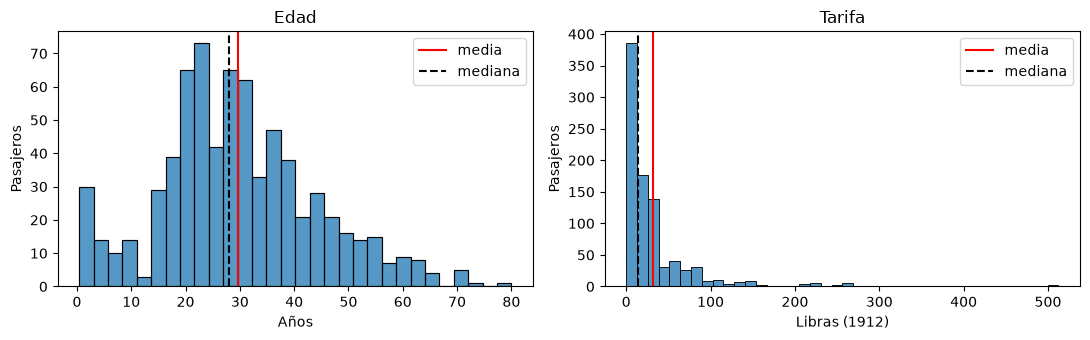

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

sns.histplot(df["age"], bins=30, ax=axes[0])
axes[0].axvline(df["age"].mean(), color="red", label="media")
axes[0].axvline(df["age"].median(), color="black", linestyle="--", label="mediana")
axes[0].set_title("Edad")
axes[0].set_xlabel("Años")
axes[0].set_ylabel("Pasajeros")
axes[0].legend()

sns.histplot(df["fare"], bins=40, ax=axes[1])
axes[1].axvline(df["fare"].mean(), color="red", label="media")
axes[1].axvline(df["fare"].median(), color="black", linestyle="--", label="mediana")
axes[1].set_title("Tarifa")
axes[1].set_xlabel("Libras (1912)")
axes[1].set_ylabel("Pasajeros")
axes[1].legend()

plt.tight_layout()
plt.show()

- `age` es casi simétrica (asimetría 0,39): media y mediana casi coinciden.
- `fare` es **muy asimétrica** (asimetría 4,79). La media (32) es más del doble de la mediana (14), por culpa de unos pocos billetes muy caros. Para describirla, mejor la mediana y el RIC. Para modelar, puede convenir una [transformación logarítmica](03-transformacion-datos.ipynb).
- `sibsp` y `parch` (familiares a bordo) son recuentos pequeños: la mayoría de los pasajeros viajaba sin familia.

### 3.4. Bivariante: categóricas frente a la objetivo

Para comparar grupos de tamaños distintos hay que mirar **proporciones**, no recuentos. `pd.crosstab(..., normalize="index")` da la tasa de supervivencia dentro de cada categoría:

In [8]:
pd.crosstab(df["sex"], df["survived"], normalize="index").round(2)

survived,0,1
sex,,
female,0.26,0.74
male,0.81,0.19


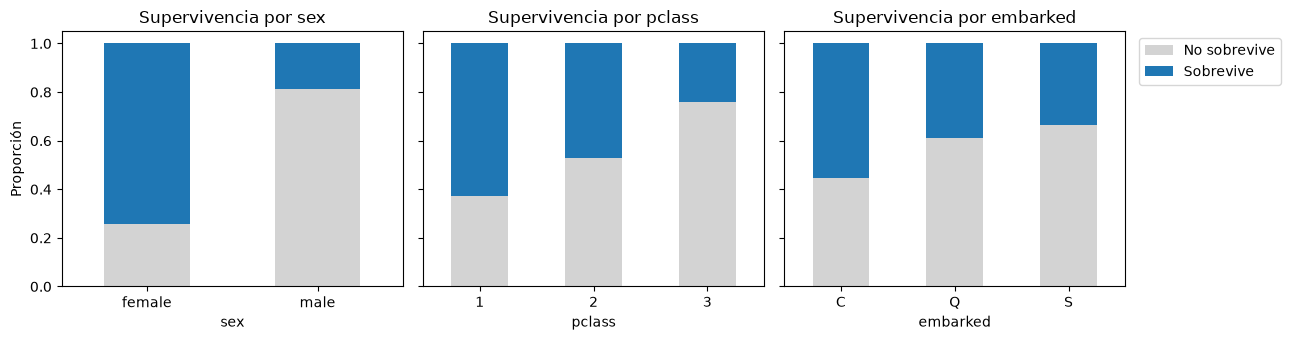

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, col in zip(axes, ["sex", "pclass", "embarked"]):
    tabla = pd.crosstab(df[col], df["survived"], normalize="index")
    tabla.plot(kind="bar", stacked=True, ax=ax, color=["lightgray", "tab:blue"], legend=False)
    ax.set_title(f"Supervivencia por {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Proporción")
    ax.tick_params(axis="x", rotation=0)
axes[-1].legend(["No sobrevive", "Sobrevive"], loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

- El **sexo** es el atributo más discriminante: sobrevive el 74 % de las mujeres y el 19 % de los hombres.
- La **clase** también: la supervivencia baja de forma clara de 1.ª a 3.ª.
- El puerto de embarque muestra diferencias menores. Probablemente reflejan la composición por clase de cada puerto, no un efecto propio.

Las variables pueden **interactuar**. La tasa de supervivencia por sexo y clase a la vez cuenta más que cada variable por separado:

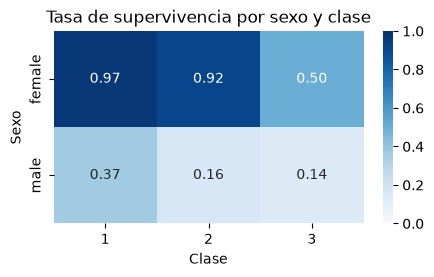

In [10]:
tasa = df.pivot_table(index="sex", columns="pclass", values="survived", aggfunc="mean")

plt.figure(figsize=(5, 2.5))
sns.heatmap(tasa, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Tasa de supervivencia por sexo y clase")
plt.xlabel("Clase")
plt.ylabel("Sexo")
plt.show()

Casi todas las mujeres de 1.ª y 2.ª clase sobrevivieron (97 % y 92 %), pero solo la mitad de las de 3.ª. En los hombres la ventaja de la 1.ª clase es mucho mayor que la diferencia entre 2.ª y 3.ª (37 % frente a 16 % y 14 %).

### 3.5. Bivariante: numéricas frente a la objetivo

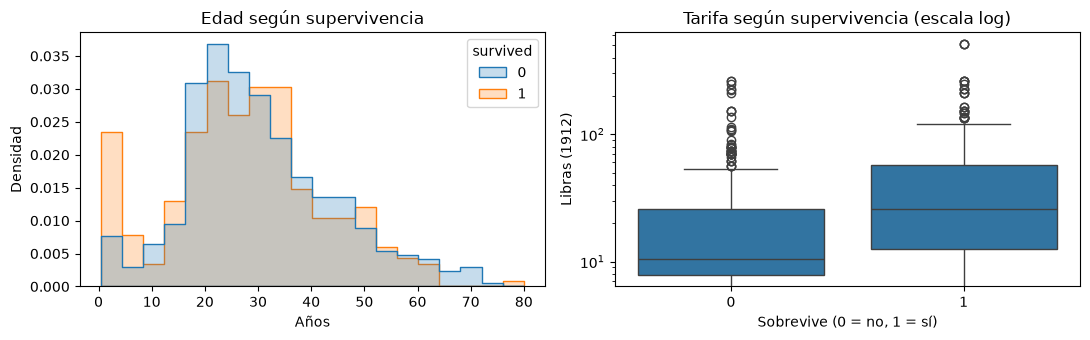

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# common_norm=False: cada grupo se normaliza por separado (ver apartado 4)
sns.histplot(data=df, x="age", hue="survived", stat="density", common_norm=False,
             bins=20, element="step", ax=axes[0])
axes[0].set_title("Edad según supervivencia")
axes[0].set_xlabel("Años")
axes[0].set_ylabel("Densidad")

sns.boxplot(data=df, x="survived", y="fare", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Tarifa según supervivencia (escala log)")
axes[1].set_xlabel("Sobrevive (0 = no, 1 = sí)")
axes[1].set_ylabel("Libras (1912)")

plt.tight_layout()
plt.show()

In [12]:
# Estadísticos robustos por grupo
df.groupby("survived")[["age", "fare"]].median()

,age,fare
survived,,
0,28.0,10.5
1,28.0,26.0


- Las distribuciones de **edad** de supervivientes y fallecidos se parecen mucho, salvo en los **niños**, que tienen más peso entre los supervivientes.
- Los supervivientes pagaron una **tarifa mediana** claramente mayor (26 frente a 10,5 libras). Es el reflejo de la clase: los billetes caros eran de 1.ª.

La escala logarítmica del diagrama de caja sirve para ver una variable tan asimétrica. Aquí es correcta porque cada caja es un grupo independiente. En barras **apiladas**, en cambio, deforma las proporciones (ver apartado 4).

### 3.6. Correlaciones

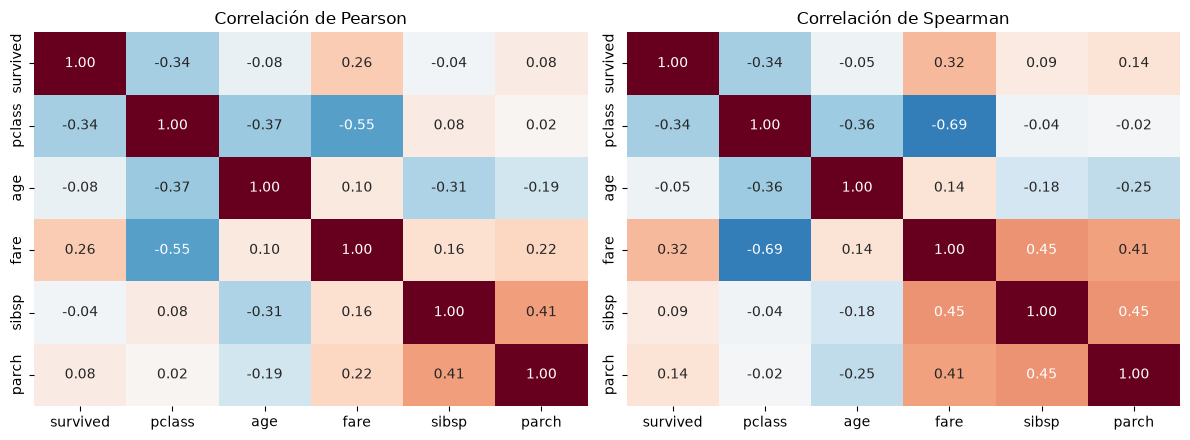

In [13]:
cols = ["survived", "pclass", "age", "fare", "sibsp", "parch"]
pearson = df[cols].corr(method="pearson")
spearman = df[cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (nombre, m) in zip(axes, [("Pearson", pearson), ("Spearman", spearman)]):
    sns.heatmap(m, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
                ax=ax, cbar=False)
    ax.set_title(f"Correlación de {nombre}")
plt.tight_layout()
plt.show()

- `fare` y `pclass` tienen correlación negativa (a mejor clase, tarifa más cara). Spearman la ve más fuerte (−0,69 frente a −0,55), porque `fare` es muy asimétrica y `pclass` es ordinal.
- `fare` con `sibsp` y `parch`: Pearson da 0,16 y 0,22, y Spearman 0,45 y 0,41. En las familias el billete se pagaba para todo el grupo. La relación es monótona pero no lineal, y los billetes más caros la tapan en Pearson.
- Con `survived`, las correlaciones más altas son `pclass` (−0,34) y `fare` (0,26–0,32). `sex` no aparece porque no es numérica, aunque en 3.4 era el atributo más discriminante: **una matriz de correlaciones no sustituye al análisis por tipos**.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Función | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `Series.value_counts` | `normalize` | Recuentos o proporciones | `True` para comparar categorías |
| | `dropna` | Si cuenta los `NaN` | Por defecto los **oculta**: usa `dropna=False` en el EDA |
| `pd.crosstab` | `normalize` | `"index"` (por fila), `"columns"` o `"all"` | `"index"` da la tasa de la objetivo dentro de cada categoría |
| `DataFrame.corr` | `method` | `"pearson"`, `"spearman"` o `"kendall"` | Spearman con asimetría, atípicos o variables ordinales |
| | `numeric_only` | Si ignora las columnas no numéricas | Por defecto `False`: da error con columnas de texto |
| `sns.histplot` | `stat` | `count`, `density`, `probability`… | `density` o `probability` para comparar grupos de tamaños distintos |
| | `common_norm` | Si normaliza todos los grupos juntos o cada uno por separado | `False` al comparar la forma de grupos desbalanceados |
| `sns.heatmap` | `vmin`, `vmax`, `center` | Rango de la escala de color | Fija `-1`, `1` y `0` en correlaciones para que el color sea comparable |

### 4.2. Errores comunes

Varios de estos errores salen de trabajar con datos reales de accidentes de tráfico, donde la gravedad del accidente era la variable objetivo (sin víctimas, heridos leves, heridos graves, fallecidos).

**1. Histogramas por clase con normalización común.** Con `stat="density"` y `hue`, seaborn normaliza por defecto sobre **todos** los datos (`common_norm=True`). La altura de cada grupo es proporcional a su tamaño, y las clases minoritarias quedan aplastadas. En los datos de accidentes, los mortales eran solo el **0,21 % (32 de 15.260)**: su histograma era invisible. Poner el eje en escala logarítmica lo "arreglaba" a medias. La solución correcta es `common_norm=False`, que normaliza cada grupo por separado y permite comparar **formas**:

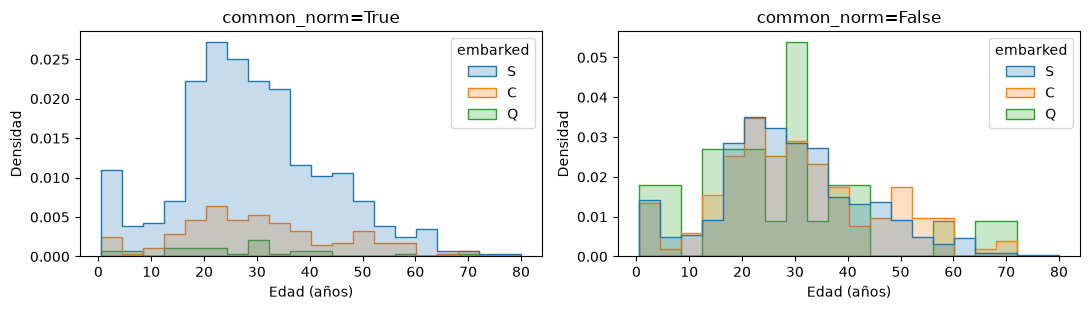

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True)
for ax, comun in zip(axes, [True, False]):
    sns.histplot(data=df, x="age", hue="embarked", stat="density", common_norm=comun,
                 bins=20, element="step", ax=ax)
    ax.set_title(f"common_norm={comun}")
    ax.set_xlabel("Edad (años)")
    ax.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

A la izquierda, el grupo `Q` (9 % de los pasajeros) casi no se ve. A la derecha ya se puede comparar su forma con la de los otros puertos. Es más irregular porque solo 28 de sus 77 pasajeros tienen la edad registrada: con tan pocos datos, cada barra depende de uno o dos pasajeros, y conviene no sobreinterpretar sus picos.

**2. Barras apiladas con escala logarítmica.** Para ver las clases minoritarias, en los datos de accidentes se usaron barras apiladas de recuentos con el eje Y en escala log. En una barra apilada, la altura de cada tramo es una **resta** entre límites, y en escala log esas diferencias ya no son proporcionales a los recuentos: la clase de arriba parece mucho más pequeña de lo que es, y la de abajo, mucho más grande. Para comparar clases dentro de cada categoría, usa **proporciones** (`crosstab(..., normalize="index")`, como en 3.4). Para ver clases muy raras, usa una tabla o un gráfico por clase.

**3. Pearson sobre una variable ordinal.** La gravedad codificada como 0, 1, 2, 3 se correlacionó con Pearson, que la trata como si las distancias entre niveles fueran iguales. Con variables ordinales (gravedad, clase, satisfacción de 1 a 5) usa **Spearman**. En 3.6, `pclass` con `fare` pasa de −0,55 a −0,69 al cambiar de método.

**4. Concluir "no hay relación" a partir de una correlación cercana a 0.** La correlación de Pearson entre `age` y `survived` es solo −0,08. Pero la supervivencia depende de la edad de forma **no lineal**: los niños sobreviven mucho más, y a partir de ahí apenas cambia:

In [15]:
print(f"Pearson(age, survived) = {df['age'].corr(df['survived']):.2f}")
tramos = pd.cut(df["age"], bins=[0, 12, 18, 30, 50, 80])
df.groupby(tramos, observed=True)["survived"].agg(["mean", "size"]).round(2)

Pearson(age, survived) = -0.08


,mean,size
age,,
"(0, 12]",0.58,69
"(12, 18]",0.43,70
"(18, 30]",0.36,270
"(30, 50]",0.42,241
"(50, 80]",0.34,64


Los menores de 12 años sobreviven un 58 %, frente a un 36 % entre los 18 y los 30. Agrupar en tramos, o simplemente mirar el gráfico, revela lo que el coeficiente esconde.

**5. `describe()` sobre códigos numéricos.** Si `pclass` o `survived` se dejan como enteros, `describe()` calcula su media y su desviación típica. La "clase media 2,31" no significa nada. La tasa de supervivencia 0,38 sí tiene sentido, pero solo porque la variable es binaria. Revisa los tipos antes de resumir (ver [limpieza de datos](02-limpieza-datos.ipynb#3.2.-Tipos-de-variable)).

**6. Resumir sin mirar los valores perdidos.** `mean()`, `describe()` y `value_counts()` **ignoran los `NaN` en silencio**. Si los valores que faltan no son aleatorios (en `age` faltan más en 3.ª clase), los estadísticos describen solo a una parte de la muestra. Revisa siempre el porcentaje de perdidos de cada variable antes de interpretar sus resúmenes.

## 5. Comparación con métodos relacionados

### 5.1. Qué gráfico usar

| Objetivo | Variables | Gráfico recomendado | Evita |
|---|---|---|---|
| Distribución | 1 numérica | Histograma, diagrama de caja | Diagrama de sectores |
| Distribución | 1 categórica | Barras ordenadas por frecuencia | Sectores con muchas categorías |
| Relación | 2 numéricas | Dispersión (con transparencia si hay muchos puntos) | Líneas si el eje X no está ordenado |
| Comparar grupos | Numérica por categórica | Cajas o histogramas por grupo (`common_norm=False`) | Solo medias sin dispersión |
| Comparar grupos | 2 categóricas | Barras al 100 % (`normalize="index"`), mapa de calor | Barras apiladas de recuentos en escala log |
| Resumen de relaciones | Muchas numéricas | Mapa de calor de correlaciones | Interpretarlo sin mirar los diagramas de dispersión |

### 5.2. Coeficientes de asociación

| Coeficiente | Tipo de variables | Mide | Robusto a atípicos |
|---|---|---|---|
| **Pearson** $r$ | Numéricas de intervalo | Relación lineal | No |
| **Spearman** $\rho$ | Numéricas u ordinales | Relación monótona (rangos) | Sí |
| **Kendall** $\tau$ | Numéricas u ordinales | Relación monótona (pares concordantes) | Sí; más fiable con muestras pequeñas y muchos empates |
| **V de Cramér** | Categóricas nominales | Asociación en una tabla de contingencia (de 0 a 1) | No aplica |
| **Tasa por grupo** (`crosstab`/`groupby`) | Categórica frente a la objetivo | Diferencia de la objetivo entre grupos | Sí |

Para un análisis más formal (contrastes de hipótesis sobre estas relaciones) ver la sección de [estadística](../02-estadistica/).

## 6. Referencias

### Fuentes

- pandas: [`DataFrame.describe`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html), [`DataFrame.corr`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) y [`crosstab`](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html).
- seaborn: [`histplot`](https://seaborn.pydata.org/generated/seaborn.histplot.html), [`boxplot`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) y [`heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html).
- Dataset: [`titanic.csv` en seaborn-data](https://github.com/mwaskom/seaborn-data), versión adaptada de los datos de la competición [*Titanic* de Kaggle](https://www.kaggle.com/c/titanic/data).

### Para saber más

- Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley. El libro que dio nombre y forma al análisis exploratorio (diagrama de caja, resúmenes robustos).
- McKinney, W. (2022). *Python for Data Analysis* (3.ª ed.). O'Reilly. Guía práctica de pandas para cargar, explorar y resumir datos; hay [versión web abierta](https://wesmckinney.com/book/).